# Regressió polinómica, metamodels i DOE

Imaginem que tenim un software que simula la física real de, per exemple, un avió. Aquest software no és IA, és un simulador, però es considera un model del mon real. És molt precís, però computacionalment molt costós. 

Al ser molt lent, és impossible provar milers d'avions al simulador per trobar el millor disseny. 

Com que no podem fer totes les proves el que fem és fer unes poques proves concretes al model real i obtindre un mostratge representatiu del comportament del model en aquestes situacions concretes. Açò és `DOE` o `Design Of Experiments`. La manera de fer les proves pot ser sistemàtica recorreguent totes les possibilitats en intervals en una graella o aleatoria. L'aleatòria és millor quan són moltes variables.  

Amb aquestes mostres, no tota la simulació, tenim un Dataset que utilitzem per entrenar un model. Aquest és una equació i és molt més ràpida que el model real. Hem fet un `Metamodel`. 

> L'entrenament d'un model per a l'escacs amb un dataset sintètic de jugades fetes per `Stockfish` podria ser un altre exemple de `metamodel` fet amb un procés `DOE`.

Començarem amb un model real que anem a suposar que és molt costós d'executar. El nostre no serà costós, però és una funció no lineal amb moltes variables. 


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Generem un Dataset per a la X amb valors aleatoris de variables que tenen una distribució normal pore donar un cert realisme. 

In [84]:

X=np.array(10*np.random.randn(37,5))
df=pd.DataFrame(X,columns=['Feature'+str(l) for l in range(1,6)])
print(df.shape)
df.head()

(37, 5)


,Feature1,Feature2,Feature3,Feature4,Feature5
0,6.655314,2.325257,7.583202,-17.107401,4.406793
1,24.441981,8.796430,-9.495822,-9.074457,11.233188
2,-3.349815,15.311057,-4.215071,-4.343142,-17.982258
3,-8.669727,-11.497020,9.782282,8.051003,14.739740
4,-1.715761,-9.419276,4.268467,-13.829604,-4.229958


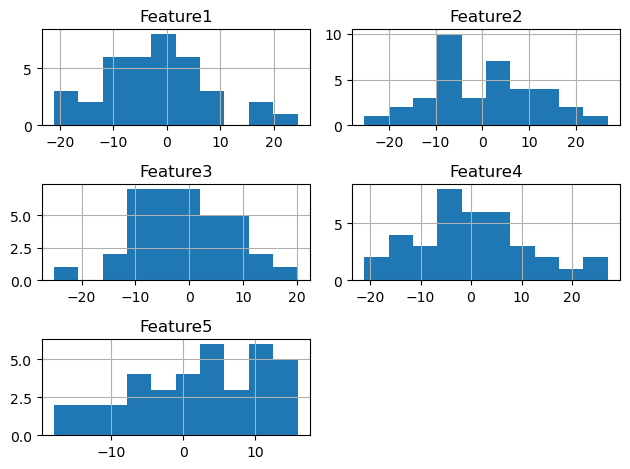

In [85]:
df.hist()
plt.tight_layout () # per a que no es solapen els gràfics

Ara generem la Y a partir de les features amb una funció `analítica` i afegim una mica de soroll gaussià.

In [86]:
df['y']=5*df['Feature1']**2+13*df['Feature2']+0.1*df['Feature3']**2*df['Feature1'] \
+2*df['Feature4']*df['Feature5']+0.1*df['Feature5']**3+0.8*df['Feature1']*df['Feature4']*df['Feature5'] \
+30*np.random.normal(loc=5,scale=2)
df.head()

,Feature1,Feature2,Feature3,Feature4,Feature5,y
0,6.655314,2.325257,7.583202,-17.107401,4.406793,-113.533207
1,24.441981,8.796430,-9.495822,-9.074457,11.233188,1406.589244
2,-3.349815,15.311057,-4.215071,-4.343142,-17.982258,-245.265317
3,-8.669727,-11.497020,9.782282,8.051003,14.739740,18.013594
4,-1.715761,-9.419276,4.268467,-13.829604,-4.229958,58.385057


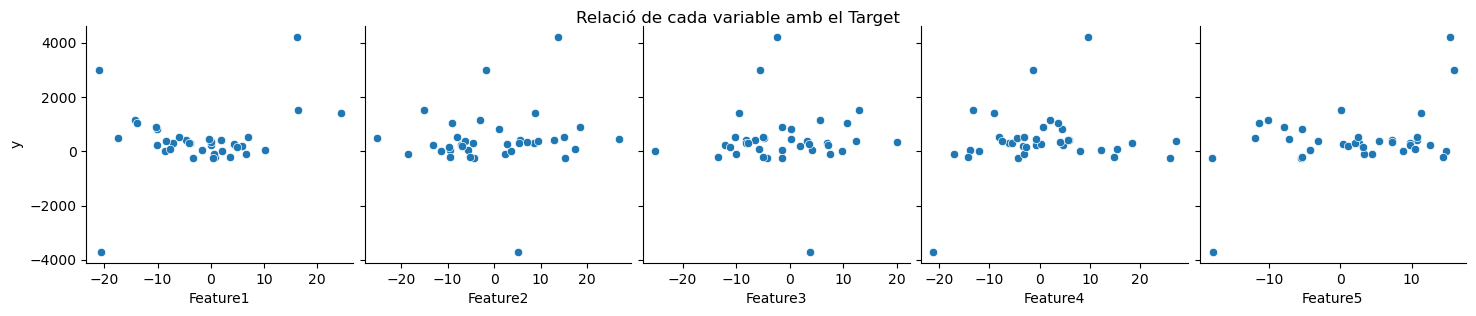

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definim quines són les columnes de les característiques (totes menys el target)
# Suposem que el teu target es diu 'y'
features = [col for col in df.columns if col != 'y']

# 2. Creem el pairplot posant les features a l'eix X i el target a l'eix Y
sns.pairplot(df, x_vars=features, y_vars=['y'], kind='scatter', height=3, aspect=1)

plt.suptitle("Relació de cada variable amb el Target", y=1.02)
plt.show()

Es veu que no hi ha una correlació lineal de les variables. 

In [88]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

linear_model = model = make_pipeline(
    StandardScaler(), 
    LinearRegression()
)
X_linear=df.drop('y',axis=1)
y_linear=df['y']
linear_model.fit(X_linear,y_linear)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Feature1','Feature2','Feature3','Feature4','Feature5']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [89]:
y_pred_linear = linear_model.predict(X_linear)
RMSE_linear = np.sqrt(np.mean((y_linear - y_pred_linear) ** 2))
R2_linear = linear_model.score(X_linear, y_linear)
print(f"RMSE (Linear Regression): {RMSE_linear:.4f}")
print(f"R^2 (Linear Regression): {R2_linear:.4f}")

RMSE (Linear Regression): 962.0733
R^2 (Linear Regression): 0.2372


In [90]:
coeff_linear = pd.DataFrame(
    linear_model.named_steps['linearregression'].coef_, # Com és un pipeline, accedim al model de regressió lineal amb named_steps
    index=df.drop('y', axis=1).columns, 
    columns=['Linear model coefficients']
)
coeff_linear

,Linear model coefficients
Feature1,176.271206
Feature2,88.283087
Feature3,116.883741
Feature4,197.805032
Feature5,407.990532


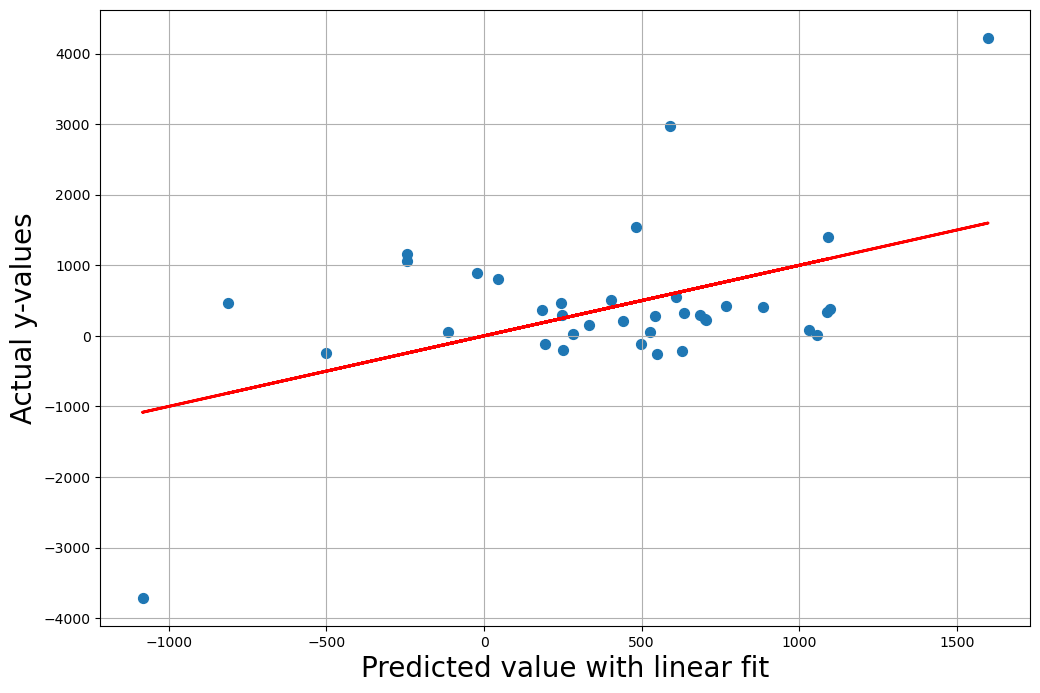

In [91]:
plt.figure(figsize=(12,8))
plt.xlabel("Predicted value with linear fit",fontsize=20)
plt.ylabel("Actual y-values",fontsize=20)
plt.grid(1)
plt.scatter(y_pred_linear,y_linear,lw=1,s=50)
plt.plot(y_pred_linear,y_pred_linear,  lw=2, color='red')

In [92]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(3, include_bias=False)

X_poly = poly.fit_transform(X_linear)

# Utilitzem get_feature_names_out() amb les columnes originals
X_poly_feature_name = poly.get_feature_names_out(['Feature'+str(l) for l in range(1, 6)])

print(X_poly_feature_name)
print(f"Nombre total de columnes generades: {len(X_poly_feature_name)}")
df_poly = pd.DataFrame(X_poly, columns=X_poly_feature_name)
df_poly['y']=df['y']
df_poly.head()


['Feature1' 'Feature2' 'Feature3' 'Feature4' 'Feature5' 'Feature1^2'
 'Feature1 Feature2' 'Feature1 Feature3' 'Feature1 Feature4'
 'Feature1 Feature5' 'Feature2^2' 'Feature2 Feature3' 'Feature2 Feature4'
 'Feature2 Feature5' 'Feature3^2' 'Feature3 Feature4' 'Feature3 Feature5'
 'Feature4^2' 'Feature4 Feature5' 'Feature5^2' 'Feature1^3'
 'Feature1^2 Feature2' 'Feature1^2 Feature3' 'Feature1^2 Feature4'
 'Feature1^2 Feature5' 'Feature1 Feature2^2' 'Feature1 Feature2 Feature3'
 'Feature1 Feature2 Feature4' 'Feature1 Feature2 Feature5'
 'Feature1 Feature3^2' 'Feature1 Feature3 Feature4'
 'Feature1 Feature3 Feature5' 'Feature1 Feature4^2'
 'Feature1 Feature4 Feature5' 'Feature1 Feature5^2' 'Feature2^3'
 'Feature2^2 Feature3' 'Feature2^2 Feature4' 'Feature2^2 Feature5'
 'Feature2 Feature3^2' 'Feature2 Feature3 Feature4'
 'Feature2 Feature3 Feature5' 'Feature2 Feature4^2'
 'Feature2 Feature4 Feature5' 'Feature2 Feature5^2' 'Feature3^3'
 'Feature3^2 Feature4' 'Feature3^2 Feature5' 'Feature3 Fe

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature1^2,Feature1 Feature2,Feature1 Feature3,Feature1 Feature4,Feature1 Feature5,...,Feature3^2 Feature4,Feature3^2 Feature5,Feature3 Feature4^2,Feature3 Feature4 Feature5,Feature3 Feature5^2,Feature4^3,Feature4^2 Feature5,Feature4 Feature5^2,Feature5^3,y
0,6.655314,2.325257,7.583202,-17.107401,4.406793,44.293201,15.475313,50.468590,-113.855119,29.328590,...,-983.760323,253.412440,2219.323913,-571.688323,147.264460,-5006.705917,1289.705973,-332.222728,85.579150,-113.533207
1,24.441981,8.796430,-9.495822,-9.074457,11.233188,597.410455,215.002181,-232.096713,-221.797709,274.561375,...,-818.249610,1012.903782,-781.940795,967.957429,-1198.225736,-747.243140,925.005516,-1145.055951,1417.454392,1406.589244
2,-3.349815,15.311057,-4.215071,-4.343142,-17.982258,11.221257,-51.289201,14.119707,14.548721,60.237230,...,-77.163855,-319.487656,-79.508407,-329.194991,-1362.992252,-81.924196,-339.197275,-1404.405505,-5814.772018,-245.265317
3,-8.669727,-11.497020,9.782282,8.051003,14.739740,75.164171,99.676031,-84.809717,-69.800002,-127.789523,...,770.424983,1410.490522,634.074337,1160.860385,2125.297863,521.855176,955.410060,1749.160351,3202.354740,18.013594
4,-1.715761,-9.419276,4.268467,-13.829604,-4.229958,2.943836,16.161227,-7.323669,23.728296,7.257597,...,-251.972721,-77.069017,816.378195,249.699511,76.373728,-2645.021868,-809.013117,-247.446810,-75.684711,58.385057


In [93]:
X_train=df_poly.drop('y',axis=1)
y_train=df_poly['y']
poly_model = model = make_pipeline(
    StandardScaler(), 
    LinearRegression()
)
poly_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](55,)","['Feature1','Feature2','Feature3',...,'Feature4^2 Feature5', 'Feature4 Feature5^2','Feature5^3']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,55
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [94]:
y_poly = poly_model.predict(X_train)
RMSE_poly=np.sqrt(np.sum(np.square(y_poly-y_train)))
print("Root-mean-square error of simple polynomial model:",RMSE_poly)
R2_poly = poly_model.score(X_train, y_train)
print(f"R^2 (Polynomial Regression): {R2_poly:.4f}")

Root-mean-square error of simple polynomial model: 7.320562875787114e-12
R^2 (Polynomial Regression): 1.0000


Un r² de 1 és sospitosament bó. Probablement tenim un cas d'`Overfitting`. 

In [95]:
# Generem un dataframe de test amb la mateixa funció que hem utilitzat per generar el dataframe d'entrenament
X_test=np.array(10*np.random.randn(100,5))
df_test=pd.DataFrame(X_test,columns=['Feature'+str(l) for l in range(1,6)])
 
# 1. Transformem les dades de test amb el poly que ja teníem
X_test_poly = poly.transform(df_test)

# 2. Creem el DataFrame de Pandas amb la matriu resultant i els noms de les columnes
df_test_poly = pd.DataFrame(
    X_test_poly, 
    columns=poly.get_feature_names_out(['Feature'+str(l) for l in range(1, 6)])
)

# 3. Ja ho tenim llest
df_test_poly.head()

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature1^2,Feature1 Feature2,Feature1 Feature3,Feature1 Feature4,Feature1 Feature5,...,Feature3^3,Feature3^2 Feature4,Feature3^2 Feature5,Feature3 Feature4^2,Feature3 Feature4 Feature5,Feature3 Feature5^2,Feature4^3,Feature4^2 Feature5,Feature4 Feature5^2,Feature5^3
0,17.422148,11.231711,11.521991,4.355313,-0.315486,303.531244,195.680530,200.737837,75.878907,-5.496441,...,1529.616695,578.195144,-41.882728,218.557777,-15.831672,1.146799,82.614844,-5.984372,0.433490,-0.031401
1,3.592045,1.261316,1.538963,-4.999720,13.755568,12.902784,4.530703,5.528025,-17.959218,49.410612,...,3.644892,-11.841376,32.578794,38.469776,-105.840642,291.195913,-124.979022,343.850715,-946.025280,2602.768558
2,1.871324,12.929956,10.292907,3.666914,1.039456,3.501853,24.196138,19.261364,6.861984,1.945159,...,1090.471023,388.487268,110.124061,138.401071,39.232400,11.121166,49.306266,13.976793,3.961986,1.123100
3,0.004763,8.551706,15.947300,11.905691,-3.859487,0.000023,0.040728,0.075949,0.056701,-0.018381,...,4055.659269,3027.812124,-981.530764,2260.457708,-732.776240,237.545261,1687.577974,-547.064888,177.342911,-57.489539
4,8.305858,-8.195492,-15.097885,2.183899,9.409245,68.987277,-68.070591,-125.400886,18.139151,78.151853,...,-3441.504266,497.811196,2144.800915,-72.008043,-310.243959,-1336.674492,10.415913,44.876573,193.349034,833.037082


In [96]:
y_test = (
    5 * df_test['Feature1']**2 + 
    13 * df_test['Feature2'] + 
    0.1 * df_test['Feature3']**2 * df_test['Feature1'] + 
    2 * df_test['Feature4'] * df_test['Feature5'] + 
    0.1 * df_test['Feature5']**3 + 
    0.8 * df_test['Feature1'] * df_test['Feature4'] * df_test['Feature5'] + 
    30 * np.random.normal(loc=5, scale=2, size=len(df_test))
)

In [97]:
# Testem el model amb el dataframe de test
y_test_pred = poly_model.predict(df_test_poly)
RMSE_test = np.sqrt(np.mean((y_test - y_test_pred) ** 2))
R2_test = poly_model.score(df_test_poly, y_test)
print(f"RMSE (Polynomial Regression on Test Set): {RMSE_test:.4f}")
print(f"R^2 (Polynomial Regression on Test Set): {R2_test:.4f}")

RMSE (Polynomial Regression on Test Set): 923.0765
R^2 (Polynomial Regression on Test Set): 0.0223


In [98]:



coeff_poly = pd.DataFrame(poly_model.named_steps['linearregression'].coef_,index=df_poly.drop('y',axis=1).columns, 
                          columns=['Coefficients polynomial model'])
coeff_poly



,Coefficients polynomial model
Feature1,-86.140664
Feature2,115.920342
Feature3,-28.641874
Feature4,6.940212
Feature5,47.125361
Feature1^2,428.522836
Feature1 Feature2,59.789408
Feature1 Feature3,-4.116834
Feature1 Feature4,30.017445
Feature1 Feature5,128.554104


Encara que tinga 1 en r² amb dades d'entrenament, té un r² molt baix amb dades de test. 

Quan li dones 55 variables a un model de LinearRegression estàndard per a només 37 punts de dades, el model té "massa llibertat". Es torna boig intentant passar exactament per sobre de tots els punts d'entrenament, assignant coeficients astronòmics i absurds. 

Millora l'entrenament amb Ridge i amb Lasso i LassoCV, compara quin ix millor. Torna a imprimir els coeficients rellevants i la comparació entre el y de test i el y predit al test. 

Explica cóm a millorat imprimint l'ecuació resultant del coeficients.  